# Fluxonium LZS: effective X $\to$ Z schedule and leakage

Single fluxonium at the half-flux sweet spot ($\Phi_{\rm ext}=\Phi_0/2$), driven by a
trapezoidal flux pulse. The pulse morphs the *effective* qubit Hamiltonian from an
X-dominated point (sweet spot) to a Z-dominated / balanced target and back.

We keep **more than two levels** so we can measure **leakage**: how far the real
multilevel evolution departs from the ideal two-level qubit.

Units: energies in GHz, times in ns ($\hbar=1$; angular factor $2\pi$ inserted only in the time evolution).

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.optimize import brentq
from scipy.signal import find_peaks

## 1. Parameters

`eps_over_delta` sets the **target** ratio $\epsilon/\Delta$ on the plateau:
$\sim 1$ gives a balanced X+Z target, $\gg 1$ a Z-dominated one.

In [32]:
# Fluxonium (GHz)
EJ, EC, EL = 9.93, 2.6, 2.04 #notion
#
#EJ, EC, EL = 3.00, 0.45, 0.50
N_osc  = 110      # oscillator levels used to build the circuit
N_keep = 8        # low-energy levels kept for the dynamics (>2 to see leakage)

# Schedule (ns)
ramp_time = 0.01 # tr : each ramp
wait_time = 0.2   # tw : plateau
dt        = 0.01

# Target effective Hamiltonian
eps_over_delta = 10.0   # ~1 balanced, >>1 Z-dominated

PHI_HALF = np.pi       # half-flux sweet spot

## 2. Circuit Hamiltonian and spectrum

$$\hat H = 4E_C\,\hat n^2 + \tfrac12 E_L\,\hat\varphi^2 - E_J\cos(\hat\varphi-\phi_{\rm ext})$$

In the LC-oscillator (Fock) basis $\hat\varphi=\varphi_{\rm zpf}(a+a^\dagger)$,
$\hat n = i\,n_{\rm zpf}(a^\dagger-a)$. Only the Josephson term carries the flux, and
$\cos(\hat\varphi-\phi_{\rm ext})=\cos\phi_{\rm ext}\cos\hat\varphi+\sin\phi_{\rm ext}\sin\hat\varphi$,
so the whole flux dependence sits in two scalars multiplying two fixed operators.
Diagonalizing $\hat H$ gives the spectrum.

In [33]:
a = qt.destroy(N_osc)
phi_zpf = (8*EC/EL)**0.25
n_zpf   = 0.5*(EL/(8*EC))**0.25
phi = phi_zpf*(a + a.dag())
n   = 1j*n_zpf*(a.dag() - a)

H_LC    = 4*EC*(n**2) + 0.5*EL*(phi**2)
cos_phi = 0.5 *((1j*phi).expm() + (-1j*phi).expm())
sin_phi = -0.5j*((1j*phi).expm() - (-1j*phi).expm())

def H_full(phi_ext):
    return H_LC - EJ*np.cos(phi_ext)*cos_phi - EJ*np.sin(phi_ext)*sin_phi

Project onto the lowest `N_keep` eigenstates at the sweet spot. This gives a small,
fast Hamiltonian that still resolves leakage into levels $|2\rangle,|3\rangle,\dots$
(raise `N_keep` until results stop changing).

In [34]:
H0 = H_full(PHI_HALF).full()
_, evecs0 = np.linalg.eigh(H0)
V = evecs0[:, :N_keep]                       # lowest N_keep eigenvectors

def reduce(op):                              # project a full operator onto the kept subspace
    return qt.Qobj(V.conj().T @ op.full() @ V)

HLC_r, cos_r, sin_r = reduce(H_LC), reduce(cos_phi), reduce(sin_phi)

def H_eff(phi_ext):                          # reduced Hamiltonian (GHz)
    return HLC_r - EJ*np.cos(phi_ext)*cos_r - EJ*np.sin(phi_ext)*sin_r

### Spectrum and potential vs external flux

Circuit spectrum $E_k-E_0$ and the flux potential $U(\varphi)=\tfrac12 E_L\varphi^2-E_J\cos(\varphi-\phi_{\rm ext})$ (with eigenlevels overlaid) for a few values of $\phi_{\rm ext}$.

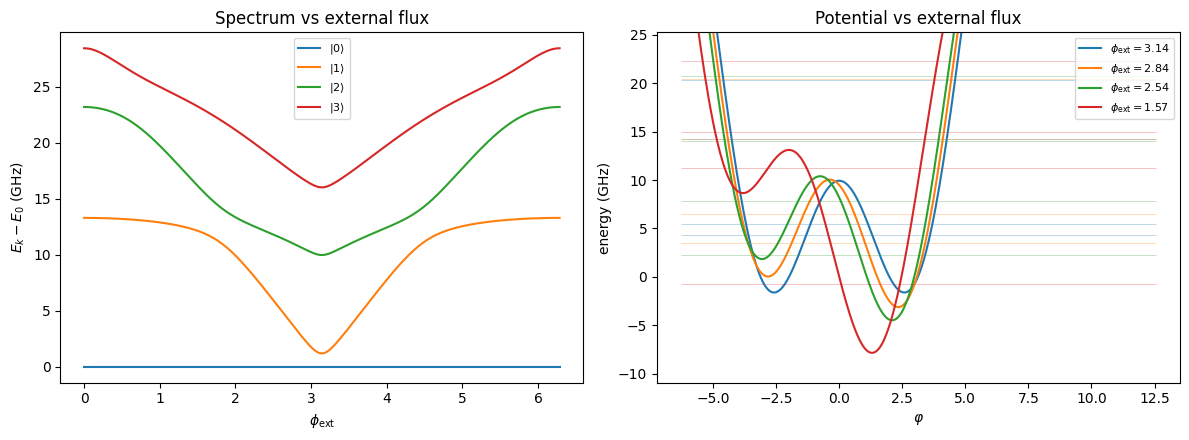

In [35]:
n_show = 4
phi_sweep = np.linspace(0, 2*np.pi, 200)
phi_grid = np.linspace(-2*np.pi, 4*np.pi, 400)

E_sweep = np.array([np.linalg.eigvalsh(H_full(pe).full())[:n_show] for pe in phi_sweep])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for k in range(n_show):
    ax[0].plot(phi_sweep, E_sweep[:, k] - E_sweep[:, 0], label=fr'$|{k}\rangle$')
ax[0].set(xlabel=r'$\phi_{\rm ext}$', ylabel=r'$E_k-E_0$ (GHz)', title='Spectrum vs external flux')
ax[0].legend(fontsize=8)

for pe in [np.pi, np.pi - 0.3, np.pi - 0.6, np.pi/2]:
    E = np.linalg.eigvalsh(H_full(pe).full())[:n_show]
    U = 0.5*EL*phi_grid**2 - EJ*np.cos(phi_grid - pe)
    line, = ax[1].plot(phi_grid, U, label=fr'$\phi_{{\rm ext}}={pe:.2f}$')
    for Ek in E:
        ax[1].hlines(Ek, phi_grid[0], phi_grid[-1], color=line.get_color(), lw=0.5, alpha=0.4)
ax[1].set(xlabel=r'$\varphi$', ylabel='energy (GHz)', title='Potential vs external flux',
          ylim=(-EJ-1, E.max()+3))
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Effective qubit Hamiltonian: $\epsilon$ and $\Delta$

The two lowest states form the qubit. In the persistent-current basis
$$H_{\rm qubit}=-\tfrac12\big(\epsilon\,\sigma_z+\Delta\,\sigma_x\big).$$

* $\Delta$ = the gap at the sweet spot (tunnel splitting) $\;\to\;$ the $\sigma_x$ term.
* Away from the sweet spot the gap opens as $E_1-E_0=\sqrt{\epsilon^2+\Delta^2}$, so
$$\boxed{\;\epsilon(\phi_{\rm ext})=\sqrt{(E_1-E_0)^2-\Delta^2}\;}$$
is the flux-controlled $\sigma_z$ field. At the sweet spot $\epsilon=0$ (pure X); detuning
the flux grows $\epsilon$ (adds Z).

We solve for the flux detuning $\delta\varphi$ that reaches the target
$\epsilon = (\texttt{eps\_over\_delta})\cdot\Delta$.

In [36]:
def gap(phi_ext):
    e = H_full(phi_ext).eigenenergies(eigvals=2)
    return e[1] - e[0]

Delta = gap(PHI_HALF)
target_gap = Delta*np.sqrt(1 + eps_over_delta**2)
dphi = brentq(lambda d: gap(PHI_HALF - d) - target_gap, 1e-3, 0.9*PHI_HALF)
print(f"Delta = {Delta:.4f} GHz,  flux detuning dphi = {dphi:.4f} rad")

Delta = 1.1887 GHz,  flux detuning dphi = 1.5696 rad


## 4. Trapezoid schedule

$$s(t)=\min\!\Big(1,\ \tfrac{1}{t_r}\min(t,\ t_f-t)\Big),\qquad t_f=2t_r+t_w,$$
$$\phi_{\rm ext}(t)=\pi-s(t)\,\delta\varphi .$$

Linear ramp up over $t_r$, flat plateau at the target for $t_w$, linear ramp down.

In [37]:
tf = 2*ramp_time + wait_time

def s_of_t(t):
    return np.minimum(1.0, np.minimum(t, tf - t)/ramp_time)

def phi_ext(t):
    return PHI_HALF - s_of_t(t)*dphi

### Plot: schedule and the effective X / Z components

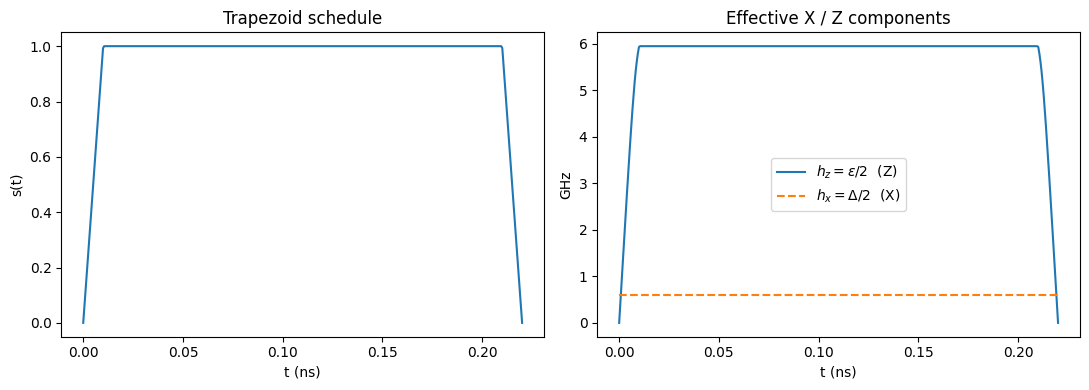

In [38]:
tg   = np.linspace(0, tf, 400)
s    = np.array([s_of_t(t) for t in tg])
gaps = np.array([gap(phi_ext(t)) for t in tg])
eps  = np.sqrt(np.maximum(gaps**2 - Delta**2, 0.0))
hx, hz = Delta/2*np.ones_like(tg), eps/2

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(tg, s); ax[0].set(xlabel='t (ns)', ylabel='s(t)', title='Trapezoid schedule')
ax[1].plot(tg, hz, label=r'$h_z=\epsilon/2$  (Z)')
ax[1].plot(tg, hx, '--', label=r'$h_x=\Delta/2$  (X)')
ax[1].set(xlabel='t (ns)', ylabel='GHz', title='Effective X / Z components'); ax[1].legend()
plt.tight_layout(); plt.show()

### Plot: X / Z components and spectrum along the flux trajectory

Here the x-axis is the **external flux itself**, and we follow the *actual pulse path*:
the flux starts at the sweet spot $\phi_{\rm ext}=\pi$, ramps **down** to the plateau
$\phi_{\rm ext}=\pi-\delta\varphi$, and ramps back **up** to $\pi$ (out and back). So each
curve is drawn twice — once for the down-ramp, once for the up-ramp — with arrows showing
the direction. This lets you read off the *strength* of the effective X ($h_x=\Delta/2$)
and Z ($h_z=\epsilon/2$) components, and the circuit spectrum, at every flux the pulse
visits.

**Which flux is held constant?** There is a single control flux $\phi_{\rm ext}(t)$; it is
*not* constant during the pulse. What is fixed is the **static bias / sweet spot**,
$\phi_{\rm ext}=\Phi_{\rm ext}=\Phi_0/2$, i.e. `PHI_HALF = π ≈ 3.14159 rad`. The pulse is a
detuning away from that bias by $\delta\varphi=$ `dphi`, so the flux only ever moves between
$\pi-\delta\varphi$ (plateau) and $\pi$ (endpoints).

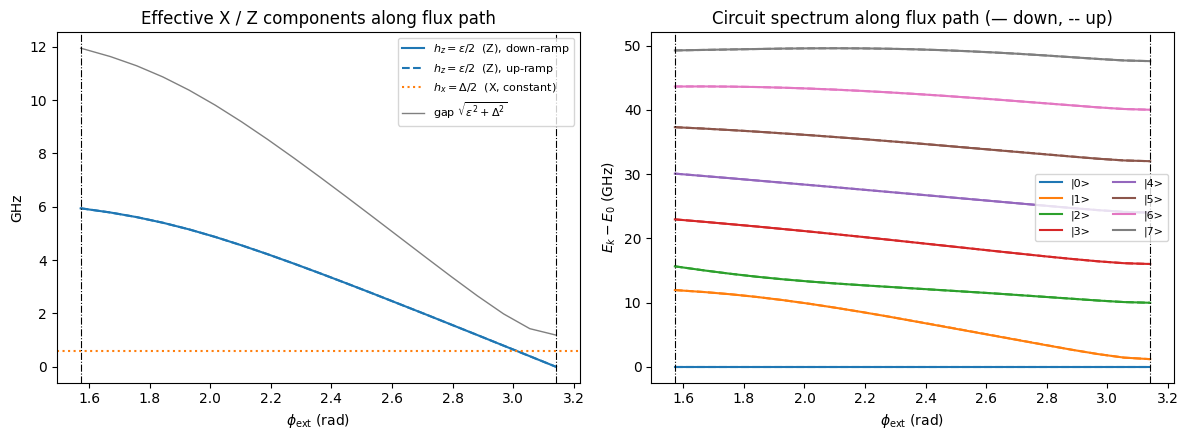

In [39]:
# Follow the flux along the ACTUAL pulse trajectory (out and back):
#   pi  ->  pi - dphi (plateau)  ->  pi
# We build the trajectory by evaluating phi_ext(t) over the full schedule, so the
# x-axis is the flux that the pulse really visits. Down-ramp and up-ramp are
# plotted separately (with direction arrows) since they retrace the same fluxes.
tg      = np.linspace(0, tf, 400)
phi_traj = phi_ext(tg)                        # flux value at each time -> the trajectory

# Split the trajectory into the down-ramp (flux decreasing) and up-ramp (increasing).
# The plateau sits in the middle at phi = pi - dphi.
i_mid = len(tg)//2
phi_down, phi_up = phi_traj[:i_mid+1], phi_traj[i_mid:]

def components_and_spectrum(phi_arr):
    g   = np.array([gap(p) for p in phi_arr])
    eps = np.sqrt(np.maximum(g**2 - Delta**2, 0.0))
    E   = np.array([np.linalg.eigvalsh(H_full(p).full())[:n_levels] for p in phi_arr])
    return g, eps, E

n_levels = 8
phi_plateau = PHI_HALF - dphi

g_d, eps_d, E_d = components_and_spectrum(phi_down)
g_u, eps_u, E_u = components_and_spectrum(phi_up)

hx = Delta/2   # X strength: flux-independent tunnel splitting

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# --- left: effective X / Z components along the flux trajectory ---
ax[0].plot(phi_down, eps_d/2, color='C0', label=r'$h_z=\epsilon/2$  (Z), down-ramp')
ax[0].plot(phi_up,   eps_u/2, color='C0', ls='--', label=r'$h_z=\epsilon/2$  (Z), up-ramp')
ax[0].axhline(hx, color='C1', ls=':', label=r'$h_x=\Delta/2$  (X, constant)')
ax[0].plot(phi_down, g_d, color='0.5', lw=1, label=r'gap $\sqrt{\epsilon^2+\Delta^2}$')
# direction arrows for the Z component
ax[0].annotate('', xy=(phi_down[-1], eps_d[-1]/2), xytext=(phi_down[len(phi_down)//2], eps_d[len(phi_down)//2]/2),
               arrowprops=dict(arrowstyle='->', color='C0'))
ax[0].annotate('', xy=(phi_up[len(phi_up)//2], eps_u[len(phi_up)//2]/2), xytext=(phi_up[0], eps_u[0]/2),
               arrowprops=dict(arrowstyle='->', color='C0'))
for x, lab in [(PHI_HALF, 'sweet spot\n$\\pi$'), (phi_plateau, 'plateau\n$\\pi-\\delta\\varphi$')]:
    ax[0].axvline(x, color='k', ls='-.', lw=0.8)
ax[0].set(xlabel=r'$\phi_{\rm ext}$ (rad)', ylabel='GHz',
          title='Effective X / Z components along flux path')
ax[0].legend(fontsize=8)

# --- right: circuit spectrum along the flux trajectory ---
for k in range(n_levels):
    ax[1].plot(phi_down, E_d[:, k] - E_d[:, 0], color=f'C{k}', label=f'|{k}>')
    ax[1].plot(phi_up,   E_u[:, k] - E_u[:, 0], color=f'C{k}', ls='--')
for x in (PHI_HALF, phi_plateau):
    ax[1].axvline(x, color='k', ls='-.', lw=0.8)
ax[1].set(xlabel=r'$\phi_{\rm ext}$ (rad)', ylabel=r'$E_k-E_0$ (GHz)',
          title='Circuit spectrum along flux path (— down, -- up)')
ax[1].legend(fontsize=8, ncol=2)

plt.tight_layout(); plt.show()


### Plot: external flux vs time

The single control flux $\phi_{\rm ext}(t)$ over the whole trapezoid pulse. This is the one
knob of the circuit: it starts at the sweet spot $\pi$ (pure X), ramps down to the plateau
$\pi-\delta\varphi$ (Z turned on), holds, and ramps back. Left axis is the **reduced flux in
radians** ($\phi_{\rm ext}=2\pi\,\Phi_{\rm ext}/\Phi_0$); right axis shows the same thing in
**units of the flux quantum** $\Phi_{\rm ext}/\Phi_0$. The green curve overlays the induced
$\sigma_z$ field $\epsilon(t)$ (right-hand annotation) so you can see the flux directly
driving the Z component.

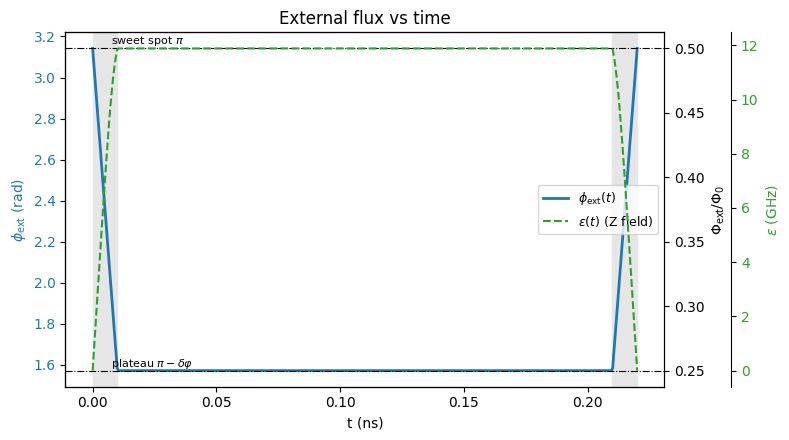

sweet-spot flux : phi_ext = 3.14159 rad  =  Phi_ext/Phi_0 = 0.5000
plateau flux    : phi_ext = 1.57197 rad  =  Phi_ext/Phi_0 = 0.2502
detuning dphi   : 1.56963 rad  =  0.2498 Phi_0


In [40]:
# External flux vs time over the full pulse (single control knob phi_ext(t)).
tg       = np.linspace(0, tf, 400)
phi_t    = phi_ext(tg)                                   # reduced flux, radians
gaps_t   = np.array([gap(p) for p in phi_t])
eps_t    = np.sqrt(np.maximum(gaps_t**2 - Delta**2, 0.0))  # induced sigma_z field

phi_plateau = PHI_HALF - dphi

fig, ax = plt.subplots(figsize=(8, 4.5))

# --- flux vs time (radians, left axis) ---
ax.plot(tg, phi_t, color='C0', lw=2, label=r'$\phi_{\rm ext}(t)$')
ax.axhline(PHI_HALF,    color='k', ls='-.', lw=0.8)
ax.axhline(phi_plateau, color='k', ls='-.', lw=0.8)
ax.text(0.02*tf, PHI_HALF,    r'  sweet spot $\pi$',            va='bottom', fontsize=8)
ax.text(0.02*tf, phi_plateau, r'  plateau $\pi-\delta\varphi$', va='bottom', fontsize=8)
# mark the ramp/plateau segments
ax.axvspan(0, ramp_time, color='0.9')
ax.axvspan(tf - ramp_time, tf, color='0.9', label='ramps')
ax.set_xlabel('t (ns)')
ax.set_ylabel(r'$\phi_{\rm ext}$ (rad)', color='C0')
ax.tick_params(axis='y', labelcolor='C0')
ax.set_title('External flux vs time')

# --- right axis: same flux in units of the flux quantum ---
axf = ax.twinx()
axf.set_ylabel(r'$\Phi_{\rm ext}/\Phi_0$')
lo, hi = ax.get_ylim()
axf.set_ylim(lo/(2*np.pi), hi/(2*np.pi))                 # phi/2pi = Phi/Phi0

# --- overlay the induced sigma_z field eps(t) on a third scale ---
axe = ax.twinx()
axe.spines['right'].set_position(('outward', 48))
axe.plot(tg, eps_t, color='C2', ls='--', lw=1.5, label=r'$\epsilon(t)$ (Z field)')
axe.set_ylabel(r'$\epsilon$ (GHz)', color='C2')
axe.tick_params(axis='y', labelcolor='C2')

# combined legend
lines = ax.get_lines()[:1] + axe.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc='center right', fontsize=9)

plt.tight_layout(); plt.show()

print(f"sweet-spot flux : phi_ext = {PHI_HALF:.5f} rad  =  Phi_ext/Phi_0 = {PHI_HALF/(2*np.pi):.4f}")
print(f"plateau flux    : phi_ext = {phi_plateau:.5f} rad  =  Phi_ext/Phi_0 = {phi_plateau/(2*np.pi):.4f}")
print(f"detuning dphi   : {dphi:.5f} rad  =  {dphi/(2*np.pi):.4f} Phi_0")


## 5. Instantaneous spectrum during the schedule

First `n_levels` eigenenergies (relative to the ground state) of the full circuit along the pulse.

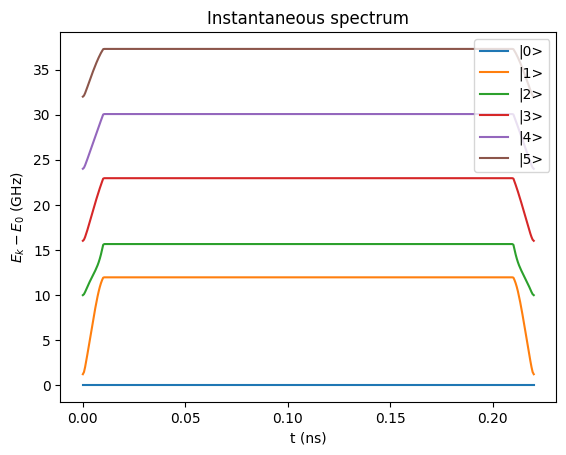

In [50]:
n_levels = 6
E = np.array([np.linalg.eigvalsh(H_full(phi_ext(t)).full())[:n_levels] for t in tg])
for k in range(n_levels):
    plt.plot(tg, E[:, k] - E[:, 0], label=f'|{k}>')
plt.xlabel('t (ns)'); plt.ylabel(r'$E_k-E_0$ (GHz)')
plt.title('Instantaneous spectrum'); plt.legend(); plt.show()

## 6. Time evolution and the LZS spectrum

Initialize in the ground state of $H(0)$ at the sweet spot, i.e. $|+\rangle$ (the $\sigma_x$
ground state) — in the projected basis this is simply `basis(N_keep, 0)`.

Evolving the **multilevel** $H(t)$ and sweeping the wait time $t_w$: the phase accumulated on
the plateau ($\propto$ plateau gap $\times\,t_w$) modulates the return probability
$|\langle\psi_0|\psi(t_f)\rangle|^2$ — Stückelberg interference. Peaks are flagged with `find_peaks`.

In [42]:
def evolve(tw, return_states=False):
    tf_ = 2*ramp_time + tw
    def pe(t):
        s = np.minimum(1.0, np.minimum(t, tf_ - t)/ramp_time)
        return PHI_HALF - s*dphi
    H = [2*np.pi*HLC_r,
         [-2*np.pi*EJ*cos_r, lambda t, args: np.cos(pe(t))],
         [-2*np.pi*EJ*sin_r, lambda t, args: np.sin(pe(t))]]
    tlist = np.linspace(0, tf_, int(tf_/dt) + 1)
    psi0 = qt.basis(N_keep, 0)                       # |+> = ground state at t=0
    res = qt.sesolve(H, psi0, tlist, options={'max_step': dt})
    return res if return_states else res.states[-1]

In [44]:
psi0    = qt.basis(N_keep, 0)
tw_list = np.linspace(0.0, 10, 2001)
P = np.array([abs(psi0.overlap(evolve(tw)))**2 for tw in tw_list])


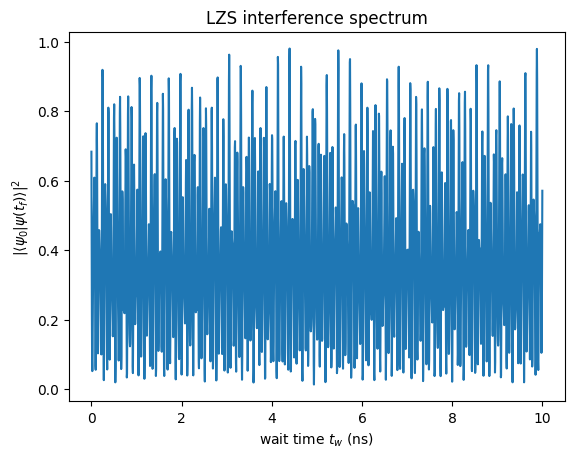

peaks at tw = [0.06 0.12 0.17 0.24 0.3  0.38 0.43 0.5  0.56 0.64 0.68 0.72 0.76 0.82
 0.89 0.94 1.02 1.07 1.15 1.2  1.28 1.33 1.4  1.46 1.51 1.53 1.58 1.64
 1.72 1.77 1.84 1.9  1.98 2.02 2.1  2.16 2.23 2.28 2.33 2.36 2.41 2.48
 2.54 2.62 2.67 2.74 2.8  2.88 2.92 2.98 3.06 3.11 3.18 3.24 3.31 3.36
 3.44 3.49 3.57 3.62 3.7  3.75 3.82 3.88 3.96 4.   4.08 4.14 4.22 4.26
 4.32 4.4  4.45 4.46 4.53 4.58 4.65 4.7  4.78 4.83 4.91 4.96 5.04 5.09
 5.16 5.22 5.3  5.34 5.42 5.48 5.55 5.6  5.66 5.74 5.79 5.86 5.92 5.99
 6.04 6.12 6.17 6.24 6.3  6.38 6.43 6.5  6.56 6.64 6.68 6.76 6.82 6.89
 6.94 7.   7.02 7.07 7.14 7.2  7.26 7.33 7.38 7.46 7.51 7.58 7.64 7.72
 7.77 7.81 7.84 7.9  7.98 8.02 8.1  8.15 8.23 8.28 8.36 8.41 8.47 8.54
 8.6  8.62 8.67 8.72 8.8  8.85 8.93 8.98 9.06 9.11 9.18 9.24 9.31 9.36
 9.44 9.5  9.56 9.62 9.7  9.75 9.8  9.88 9.96]
heights     = [0.609 0.766 0.458 0.92  0.59  0.811 0.504 0.82  0.724 0.842 0.569 0.228
 0.691 0.843 0.812 0.647 0.575 0.896 0.728 0.737 0.475 0.903 0.619 0.82

In [45]:
peaks, _ = find_peaks(P, height=0.05, distance=3)
plt.plot(tw_list, P)
# plt.plot(tw_list[peaks], P[peaks], 'rv')
# for i in peaks:
#     plt.annotate(f'{P[i]:.2f}', (tw_list[i], P[i]),
#                  textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
plt.xlabel('wait time $t_w$ (ns)'); plt.ylabel(r'$|\langle\psi_0|\psi(t_f)\rangle|^2$')
plt.title('LZS interference spectrum'); plt.show()

print("peaks at tw =", np.round(tw_list[peaks], 2))
print("heights     =", np.round(P[peaks], 3))

## 8. Fourier analysis of the interference signal (reusing the LZS project)

Extract the Stückelberg oscillation frequencies from `P(tw_list)` with the
project's `fourier_analysis` + `fit_decay_rates`, and compare against the true
qubit gap on the plateau.

**Units.** The evolution uses `2π·H` with `t` in ns and `H` in GHz, so an energy
gap `ΔE` (GHz) oscillates the signal at *ordinary* frequency `f = ΔE`.
`fourier_analysis` returns ordinary `f`, so detected `f` compares directly to the
plateau gap in GHz.

**Scope.** For these parameters the signal is essentially a *single-tone* qubit
oscillation (the ~0.5 GHz plateau gap). Higher circuit transitions sit near
~12 GHz and are far above the Nyquist limit of the `tw` sampling (Δtw = 0.1 ns →
Nyquist ≈ 5 GHz), so they cannot be resolved from this signal. The full
turnpike / `u_m` reconstruction needs several comparable, resolved transitions,
so it is not applied here — a finer `tw` grid (or a multi-level regime) would be
required to exercise it.

In [46]:
# Reuse the project's diagnostics functions. This notebook lives in notebooks/,
# so src/ is one directory up.
import os, sys
SRC = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if SRC not in sys.path:
    sys.path.append(SRC)

# Global fit stays from the shared multi-qubit module.
from fourier import fit_decay_rates

# Fluxonium-specific peak detection + model-free leakage live in their own
# package (src/fluxonium/), separate from the multi-qubit tooling. The peak
# finder detects ALL peaks (no fixed count) and suppresses only the sidelobes
# of the tallest peaks; the leakage module estimates leakage from the signal
# alone, without the Hamiltonian. `integrate_peak_areas` integrates the FFT
# under each detected peak so the leakage ratio uses genuine peak AREAS instead
# of a single-bin height.
from fluxonium import (analyze_peaks, find_all_peaks, integrate_peak_areas,
                       leakage_report)

True plateau qubit gap = 11.94603 GHz
tw sampling: dtw = 0.005 ns  ->  Nyquist = 100.000 GHz


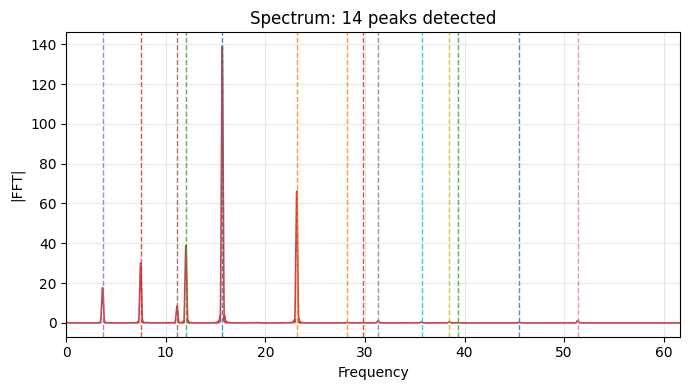


  #       Frequency   Phase (rad)         Amp
----------------------------------------------
  1       15.676083        0.7281     0.27580
  2       23.152794        1.6769     0.13064
  3       12.020562        1.2599     0.07695
  4        7.476688        0.9456     0.05956
  5        3.655524        5.7545     0.03517
  6       11.132655        0.4172     0.01674
  7       51.364206        3.4263     0.00239
  8       31.320439        1.2813     0.00212
  9       38.479640        1.9205     0.00135
 10       35.688098        2.6950     0.00109
 11       45.500803        4.8975     0.00060
 12       28.211393        1.7499     0.00052
 13       39.343431        2.1679     0.00031
 14       29.824568        4.1656     0.00027
detected ordinary freqs (GHz): [ 3.65552  7.47669 11.13266 12.02056 15.67608 23.15279 28.21139 29.82457
 31.32044 35.6881  38.47964 39.34343 45.5008  51.36421]


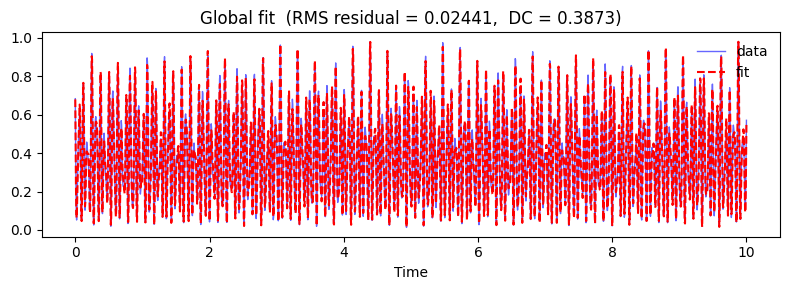


Peak areas (integral of |FFT|**1 under each peak):
  f =  3.65552 GHz   amp =   0.01752   area =      3.75235
  f =  7.47669 GHz   amp =   0.02976   area =      6.32270
  f = 11.13266 GHz   amp =   0.00828   area =      1.75820
  f = 12.02056 GHz   amp =   0.03873   area =      8.07317
  f = 15.67608 GHz   amp =   0.13815   area =     28.98981
  f = 23.15279 GHz   amp =   0.06599   area =     13.79112
  f = 28.21139 GHz   amp =   0.00026   area =      0.07277
  f = 29.82457 GHz   amp =   0.00013   area =      0.02847
  f = 31.32044 GHz   amp =   0.00107   area =      0.23074
  f = 35.68810 GHz   amp =   0.00054   area =      0.11475
  f = 38.47964 GHz   amp =   0.00068   area =      0.14052
  f = 39.34343 GHz   amp =   0.00015   area =      0.03261
  f = 45.50080 GHz   amp =   0.00030   area =      0.06247
  f = 51.36421 GHz   amp =   0.00120   area =      0.25229

Dominant tone: f = 15.67608 GHz   (true gap 11.94603 GHz, error 3730.06 MHz)
DC (fitted): 0.3873   DC (mean): 0.3868


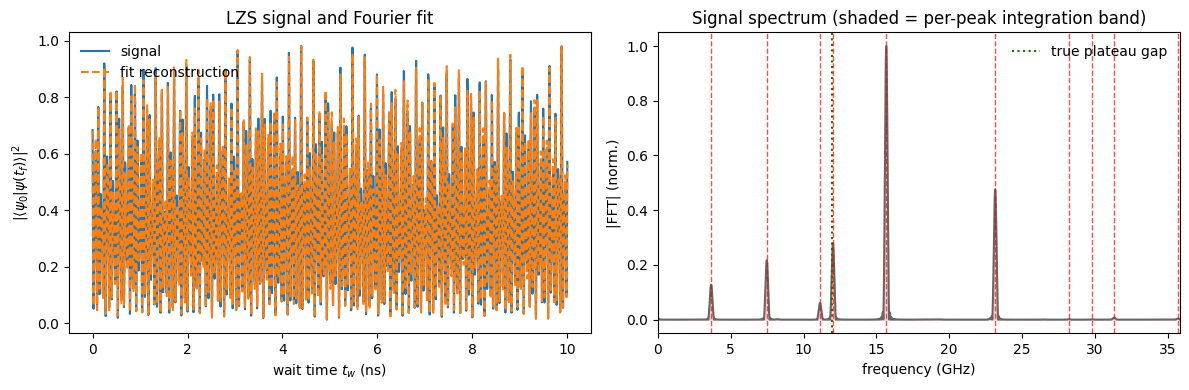

In [47]:
# --- Fourier analysis of the fluxonium LZS signal P(tw_list) -----------------
# True qubit gap on the plateau (s=1), for reference. Ordinary frequency of the
# Stuckelberg oscillation equals this gap in GHz.
phi_plateau = PHI_HALF - dphi
gap_plateau = gap(phi_plateau)                      # GHz
print(f"True plateau qubit gap = {gap_plateau:.5f} GHz")

# Nyquist limit of the wait-time sampling.
dtw = tw_list[1] - tw_list[0]
f_nyq = 0.5 / dtw
print(f"tw sampling: dtw = {dtw:.3f} ns  ->  Nyquist = {f_nyq:.3f} GHz")

# 1. Peak detection with the fluxonium finder:
#      * no fixed peak count -- every mode that survives the gates is returned,
#        so we do not need to know the number of transitions in advance;
#      * peak-relative sidelobe suppression -- only the skirts of the TALLEST
#        peaks are rejected, so weak genuine tones elsewhere are kept and
#        resolution is not sacrificed. Raise `sidelobe_safety` if skirts of the
#        dominant peak still leak through; lower `detect_prominence` to reach
#        fainter tones.
#    `return_full=True` also hands back the full detector result (`peak_res`)
#    with the spectrum (`mag`, `frq`) and accepted-peak indices, which we need
#    below to integrate the AREA under each peak.
exp_freqs, exp_phases, peak_res = analyze_peaks(
    P, tw_list,
    zero_pad_factor=8,
    window='hann',
    detect_prominence=0.0002,      # baseline faint-peak sensitivity
    prominence_threshold=0.0001,   # final floor vs the strongest peak
    sidelobe_suppression=True,
    sidelobe_safety=2,
    f_min=None,                   # analyse the full band
    plot=True, verbose=True,
    return_full=True,
)
print("detected ordinary freqs (GHz):", np.round(np.sort(exp_freqs), 5))

# 2. Global fit -> amplitudes, decay rates, DC (no dephasing modelled here).
exp_amps, exp_lambdas, dc_fit = fit_decay_rates(
    P, tw_list, exp_freqs, exp_phases, noise=False
)

# 2b. Peak AREAS: integrate the FFT under each detected peak lobe. This is the
#     accurate per-tone weight for the spectral-leakage ratio -- the integral of
#     |FFT| over the whole lobe, NOT the single-bin height. Each peak owns the
#     band out to the valley (local minimum) between it and its neighbours, so
#     the areas partition the spectrum and add up without double counting.
#       * power=1 -> integrate |FFT|      (magnitude; the default here).
#       * power=2 -> integrate |FFT|**2   (power/energy, Parseval-conserved).
#     Switch to power=2 for a physically-conserved power fraction. `freqs_ref`
#     aligns the returned areas to exp_freqs / exp_amps.
AREA_POWER = 1                     # <- set to 2 for the |FFT|**2 (Parseval) area
area_res = integrate_peak_areas(
    peak_res['mag'], peak_res['frq'], peak_res['accepted_idx'],
    power=AREA_POWER, freqs_ref=exp_freqs,
)
exp_areas = area_res['areas']      # per-tone peak area, aligned to exp_freqs

print(f"\nPeak areas (integral of |FFT|**{AREA_POWER} under each peak):")
for f, A, ar in sorted(zip(exp_freqs, exp_amps, exp_areas)):
    print(f"  f = {f:8.5f} GHz   amp = {A:9.5f}   area = {ar:12.5f}")

# Dominant detected tone vs the true gap.
k_dom = int(np.argmax(exp_amps))
f_dom = exp_freqs[k_dom]
print(f"\nDominant tone: f = {f_dom:.5f} GHz   (true gap {gap_plateau:.5f} GHz, "
      f"error {abs(f_dom - gap_plateau)*1e3:.2f} MHz)")
print(f"DC (fitted): {dc_fit:.4f}   DC (mean): {np.mean(P):.4f}")

# 3. Reconstruct the signal from the fitted tones and overlay on the data.
def reconstruct(t):
    y = np.full_like(t, dc_fit)
    for A, lam, f, ph in zip(exp_amps, exp_lambdas, exp_freqs, exp_phases):
        y += 2 * A * np.exp(-lam * t) * np.cos(2 * np.pi * f * t + ph)
    return y

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(tw_list, P, label='signal')
ax[0].plot(tw_list, reconstruct(tw_list), '--', lw=1.5, label='fit reconstruction')
ax[0].set(xlabel='wait time $t_w$ (ns)',
          ylabel=r'$|\langle\psi_0|\psi(t_f)\rangle|^2$',
          title='LZS signal and Fourier fit')
ax[0].legend(frameon=False)

# Spectrum with detected tones, the true plateau gap, and each peak's
# integration band shaded so you can see exactly what was integrated.
win = np.hanning(len(P))
Y = np.abs(np.fft.rfft((P - P.mean()) * win, n=64 * len(P)))
fgrid = np.fft.rfftfreq(64 * len(P), dtw)
ax[1].plot(fgrid, Y / Y.max(), color='0.4')
ax[1].axvline(gap_plateau, color='green', ls=':', lw=1.5, label='true plateau gap')
for f in exp_freqs:
    ax[1].axvline(f, color='red', ls='--', lw=1.0, alpha=0.7)
# Shade the per-peak integration bands (from area_res['bounds'], aligned to exp_freqs).
mag_n = peak_res['mag'] / peak_res['mag'].max()
for j, (lo, hi) in enumerate(area_res['bounds']):
    ax[1].fill_between(peak_res['frq'][lo:hi + 1], 0, mag_n[lo:hi + 1],
                       alpha=0.15, color='red')
ax[1].set(xlabel='frequency (GHz)', ylabel='|FFT| (norm.)',
          title='Signal spectrum (shaded = per-peak integration band)',
          xlim=(0, min(f_nyq, 3 * gap_plateau)))
ax[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## 7. Leakage

$$\mathcal L(t)=1-\sum_{k=0,1}\big|\langle e_k(t)\,|\,\psi(t)\rangle\big|^2,$$
with $|e_k(t)\rangle$ the *instantaneous* eigenstates of $H(t)$. Nonzero $\mathcal L$ = population
pushed into $|2\rangle,|3\rangle,\dots$ by the (fast) ramps. Sharper ramps and larger detunings
leak more; converge in `N_keep`.

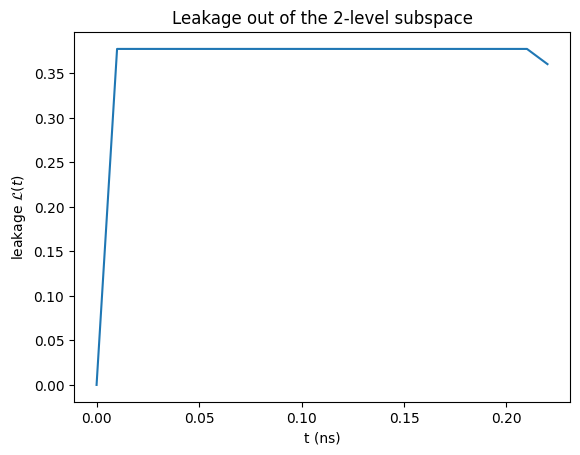

max leakage = 0.3775543713099646


In [48]:
res = evolve(wait_time, return_states=True)

def leak_at(t, psi):
    Hm = H_eff(phi_ext(t)).full()
    _, ev = np.linalg.eigh(Hm)
    Pc = ev[:, :2] @ ev[:, :2].conj().T
    v = psi.full().flatten()
    return 1 - np.real(v.conj() @ Pc @ v)

leak = [leak_at(t, psi) for t, psi in zip(res.times, res.states)]
plt.plot(res.times, leak)
plt.xlabel('t (ns)'); plt.ylabel(r'leakage $\mathcal{L}(t)$')
plt.title('Leakage out of the 2-level subspace'); plt.show()
print("max leakage =", np.max(leak))

## 7b. Model-free leakage from the signal alone

The plot above uses the Hamiltonian (instantaneous eigenstates) to compute the
*exact* $\mathcal L(t)$. Here we instead ask: **how much can we say about leakage
from the measured signal $P(t_w)$ only, without the Hamiltonian?**

Physical picture. An ideal leak-free 2-level LZS signal is a single damped tone at
the plateau gap on top of a DC offset. Leakage into $|2\rangle,|3\rangle,\dots$
**opens secondary tones** at the other level-gaps — extra spectral peaks that are
absent in the clean case. So the secondary peaks *do* inform on leakage.

From a **single experiment** we form the spectral-leakage proxy

$$L_{\rm spec} = \frac{P_{\rm secondary}}{P_{\rm total}},$$

the fraction of oscillation weight that does **not** sit in the dominant
(qubit-gap) tone. We report it two ways, differing only in the per-tone weight:

* **`L_spec` (area)** — weight = the integrated area under each peak (the
  integral of the FFT over the peak's lobe). This is the accurate version: it
  does not over-weight the tallest peak the way squared heights do, and it is
  tied to a conserved quantity.
* **`L_spec` (height)** — weight = the tone height. The earlier, simpler proxy,
  shown alongside for comparison.

$L_{\rm spec}$ rises monotonically with true leakage and bounds it; it needs no
reference run. A no-leakage reference is needed only to turn it into an
*absolute calibrated* number; if that reference is not accessible (e.g. ramps
cannot be made slow enough), the proxy still ranks and bounds leakage. We also
cross-check it against the exact $\mathcal L$ above, which is available here
because we do know the Hamiltonian.

Model-free spectral leakage (single experiment, no Hamiltonian)
--------------------------------------------------------------
  dominant tone            : f = 12.0205621961461   A = 0.03873
  secondary tones          : 13
  L_spec (peak area)       : 0.8731
  L_spec (peak height)     : 0.8721

Cross-check vs exact leakage (Hamiltonian-based):
  exact  max L(t)         : 0.3776
  exact  plateau-avg L    : 0.3776
  proxy  L_spec (area)    : 0.8731
  proxy  L_spec (height)  : 0.8721
  (proxies are model-free lower-bound/monotonic indicators, not exact L)


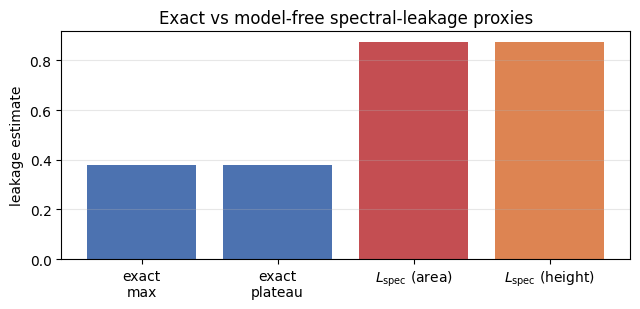

In [49]:
# --- Model-free spectral leakage from P(tw_list) -----------------------------
# Uses only the tones extracted above (exp_freqs / exp_amps) and their integrated
# peak AREAS (exp_areas) -- NO Hamiltonian.
#
# L_spec = P_secondary / P_total, the fraction of oscillation weight NOT in the
# dominant (qubit-gap) tone. Reported two ways:
#   L_spec (area)   -- weights are the integrated peak areas (accurate, unbiased;
#                      does not over-weight the tallest peak the way amp**2 does).
#   L_spec (height) -- weights are the tone heights (the earlier, simpler proxy).
report = leakage_report(
    exp_freqs, exp_amps, dc_fit,
    f_gap=gap_plateau,      # dominant tone = the known plateau qubit gap
    dom_tol=2.0 / (tw_list[-1] - tw_list[0]),   # ~2 raw FFT bins: absorb a split main peak
    power=exp_areas,        # L_spec ratio uses integrated peak areas
    verbose=True,
)

# --- Cross-check the two L_spec proxies against the EXACT leakage (needs the
# Hamiltonian). `leak` (from the cell above) is L(t) over the pulse for
# tw = wait_time. Two natural scalar summaries: the peak and the plateau-average.
L_exact_max = float(np.max(leak))
tarr = np.asarray(res.times)
plateau_mask = (tarr >= ramp_time) & (tarr <= ramp_time + wait_time)
L_exact_plateau = float(np.mean(np.asarray(leak)[plateau_mask])) if plateau_mask.any() else float('nan')

print("\nCross-check vs exact leakage (Hamiltonian-based):")
print(f"  exact  max L(t)         : {L_exact_max:.4f}")
print(f"  exact  plateau-avg L    : {L_exact_plateau:.4f}")
print(f"  proxy  L_spec (area)    : {report['L_spec']:.4f}")
print(f"  proxy  L_spec (height)  : {report['L_spec_height']:.4f}")
print("  (proxies are model-free lower-bound/monotonic indicators, not exact L)")

# Bar comparison.
labels = ['exact\nmax', 'exact\nplateau', r'$L_{\rm spec}$ (area)',
          r'$L_{\rm spec}$ (height)']
vals   = [L_exact_max, L_exact_plateau, report['L_spec'], report['L_spec_height']]
plt.figure(figsize=(6.5, 3.2))
plt.bar(labels, vals, color=['#4c72b0', '#4c72b0', '#c44e52', '#dd8452'])
plt.ylabel('leakage estimate')
plt.title('Exact vs model-free spectral-leakage proxies')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
3rfqrfrgrgrg

SyntaxError: invalid decimal literal (2444561307.py, line 1)

## 7c. Leakage vs ramp time

Run the whole pipeline (evolve $\to$ Fourier $\to$ peak areas $\to$ leakage) for a
series of ramp times $t_r$ at a fixed `eps_over_delta`, and plot the exact
max leakage and the model-free `L_spec` (area-based) against $t_r$. Faster
(shorter) ramps are more sudden and should leak more. The figure and the
underlying data are saved to `results/`.

sweep: eps/Delta = 10, dphi = 1.5696 rad, plateau gap = 11.94603 GHz


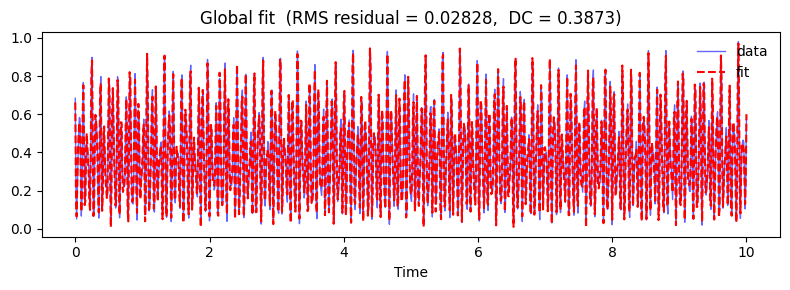

  [ 1/10] tr = 0.010 ns   exact_max = 0.3776   L_spec = 0.8728


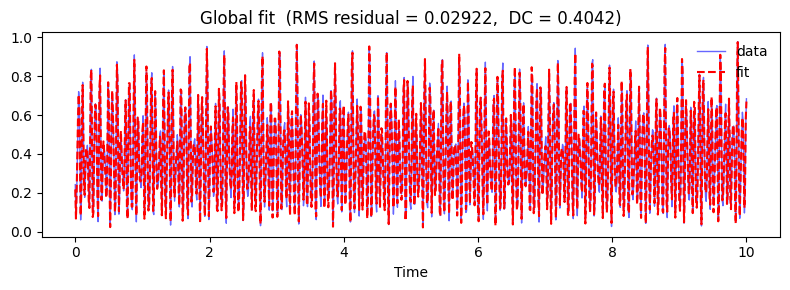

  [ 2/10] tr = 0.020 ns   exact_max = 0.5135   L_spec = 0.8400


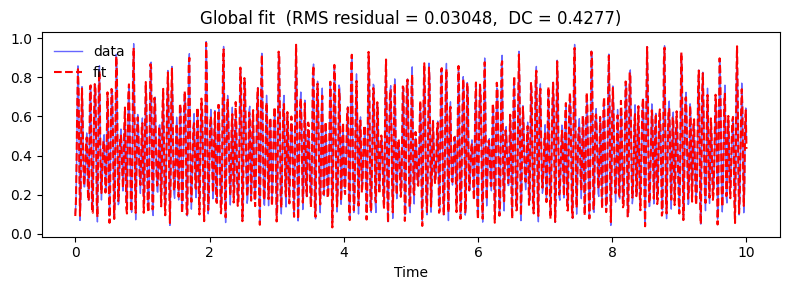

  [ 3/10] tr = 0.030 ns   exact_max = 0.6730   L_spec = 0.7869


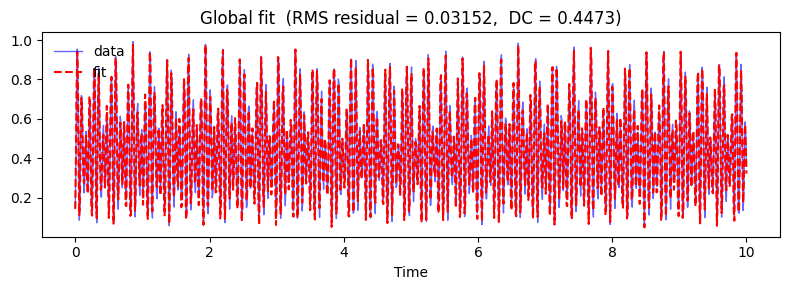

  [ 4/10] tr = 0.040 ns   exact_max = 0.5343   L_spec = 0.7196


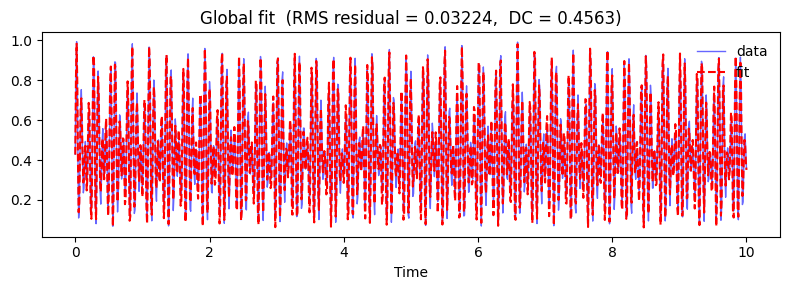

  [ 5/10] tr = 0.050 ns   exact_max = 0.3838   L_spec = 0.6465


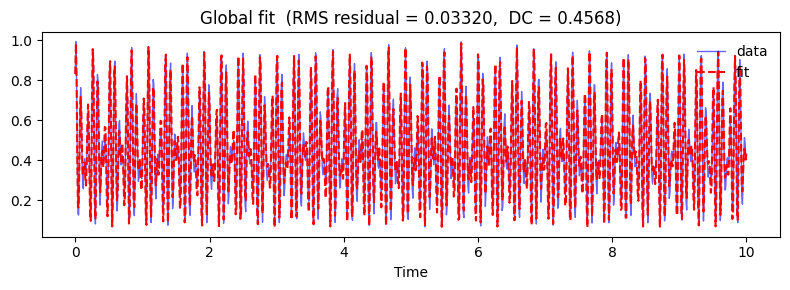

  [ 6/10] tr = 0.060 ns   exact_max = 0.2708   L_spec = 0.5732


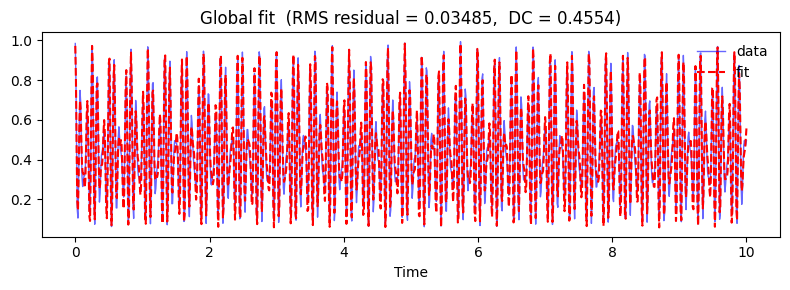

  [ 7/10] tr = 0.070 ns   exact_max = 0.1787   L_spec = 0.5013


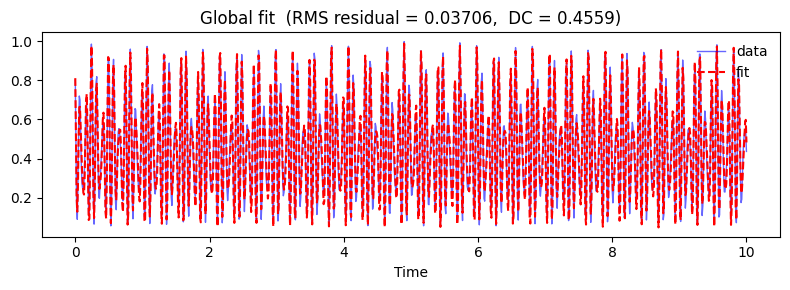

  [ 8/10] tr = 0.080 ns   exact_max = 0.1355   L_spec = 0.4283


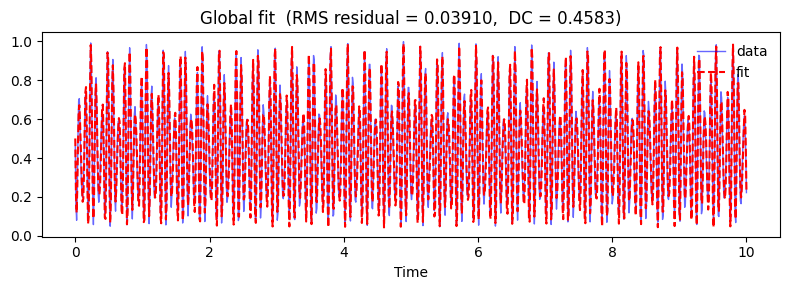

  [ 9/10] tr = 0.090 ns   exact_max = 0.1155   L_spec = 0.3757


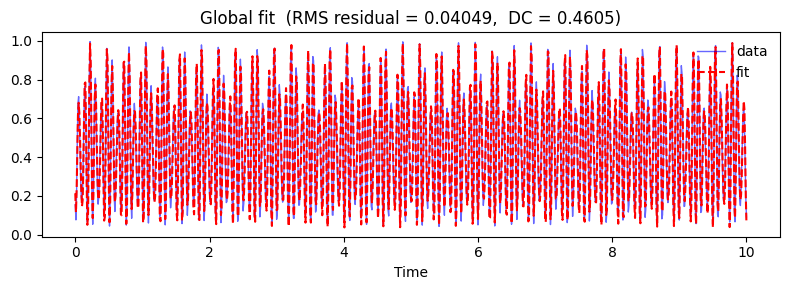

  [10/10] tr = 0.100 ns   exact_max = 0.1031   L_spec = 0.3436


In [51]:
# --- Sweep: leakage vs ramp time --------------------------------------------
# Set eps_over_delta and the list of ramp times; every ramp time runs a full
# instance of the experiment (evolve -> Fourier -> peak areas -> leakage).
# Produces two curves vs t_r: exact max leakage and model-free L_spec (area).
import json, datetime

# --- sweep configuration ---
sweep_eps_over_delta = 10                     # fixed target ratio for the sweep
ramp_times = np.linspace(0.01, 0.1, 10)          # ramp times t_r (ns) to scan   
tw_list = np.linspace(0.0, 10, 1001) 
sweep_wait_time = wait_time                  # plateau length held fixed
AREA_POWER_SWEEP = AREA_POWER                    # reuse the |FFT|**AREA_POWER area

# --- flux detuning for THIS eps_over_delta (independent of ramp time) ---
_target_gap = Delta * np.sqrt(1 + sweep_eps_over_delta**2)
dphi_sweep = brentq(lambda d: gap(PHI_HALF - d) - _target_gap, 1e-3, 0.9 * PHI_HALF)
gap_plateau_sweep = gap(PHI_HALF - dphi_sweep)
print(f"sweep: eps/Delta = {sweep_eps_over_delta}, dphi = {dphi_sweep:.4f} rad, "
      f"plateau gap = {gap_plateau_sweep:.5f} GHz")


def run_instance(tr, tw_list_):
    """One experiment at ramp time `tr`: return (P, L_exact_max, L_spec_area)."""

    def s_of(t, tf_):                       # trapezoid schedule fraction for this tr
        return np.minimum(1.0, np.minimum(t, tf_ - t) / tr)

    # Multilevel evolution for a given wait time, with tr / dphi_sweep baked in.
    def evolve_tr(tw, return_states=False):
        tf_ = 2 * tr + tw
        def pe(t):
            return PHI_HALF - s_of(t, tf_) * dphi_sweep
        H = [2 * np.pi * HLC_r,
             [-2 * np.pi * EJ * cos_r, lambda t, args: np.cos(pe(t))],
             [-2 * np.pi * EJ * sin_r, lambda t, args: np.sin(pe(t))]]
        tlist = np.linspace(0, tf_, int(tf_ / dt) + 1)
        psi0_ = qt.basis(N_keep, 0)
        r = qt.sesolve(H, psi0_, tlist, options={'max_step': dt})
        return r if return_states else r.states[-1]

    # 1. Interference signal P(tw).
    psi0_ = qt.basis(N_keep, 0)
    P_ = np.array([abs(psi0_.overlap(evolve_tr(tw))) ** 2 for tw in tw_list_])

    # 2. Model-free L_spec (area-based) from P(tw).
    f_, ph_, pr_ = analyze_peaks(
        P_, tw_list_, zero_pad_factor=8, window='hann',
        detect_prominence=0.002, prominence_threshold=0.001,
        sidelobe_suppression=True, sidelobe_safety=2.0, f_min=None,
        plot=False, verbose=False, return_full=True)
    a_, lam_, dc_ = fit_decay_rates(P_, tw_list_, f_, ph_, noise=False)
    areas_ = integrate_peak_areas(pr_['mag'], pr_['frq'], pr_['accepted_idx'],
                                  power=AREA_POWER_SWEEP, freqs_ref=f_)['areas']
    rep_ = leakage_report(f_, a_, dc_, f_gap=gap_plateau_sweep,
                          dom_tol=2.0 / (tw_list_[-1] - tw_list_[0]),
                          power=areas_, verbose=False)
    L_spec_area = rep_['L_spec']

    # 3. Exact max leakage over the pulse at tw = sweep_wait_time (needs H).
    tf_ = 2 * tr + sweep_wait_time
    r_states = evolve_tr(sweep_wait_time, return_states=True)
    def leak_at(t, psi):
        Hm = H_eff(PHI_HALF - s_of(t, tf_) * dphi_sweep).full()
        _, ev = np.linalg.eigh(Hm)
        Pc = ev[:, :2] @ ev[:, :2].conj().T
        v = psi.full().flatten()
        return 1 - np.real(v.conj() @ Pc @ v)
    L_exact_max = float(np.max([leak_at(t, psi)
                                for t, psi in zip(r_states.times, r_states.states)]))

    return P_, L_exact_max, L_spec_area


# --- run the sweep ---
tw_sweep = tw_list                                # reuse the same wait-time grid
L_exact_list, L_spec_list, P_all = [], [], []
for i, tr in enumerate(ramp_times):
    P_i, Lmax_i, Lspec_i = run_instance(tr, tw_sweep)
    L_exact_list.append(Lmax_i)
    L_spec_list.append(Lspec_i)
    P_all.append(P_i)
    print(f"  [{i+1:>2}/{len(ramp_times)}] tr = {tr:.3f} ns   "
          f"exact_max = {Lmax_i:.4f}   L_spec = {Lspec_i:.4f}")

L_exact_arr = np.array(L_exact_list)
L_spec_arr = np.array(L_spec_list)


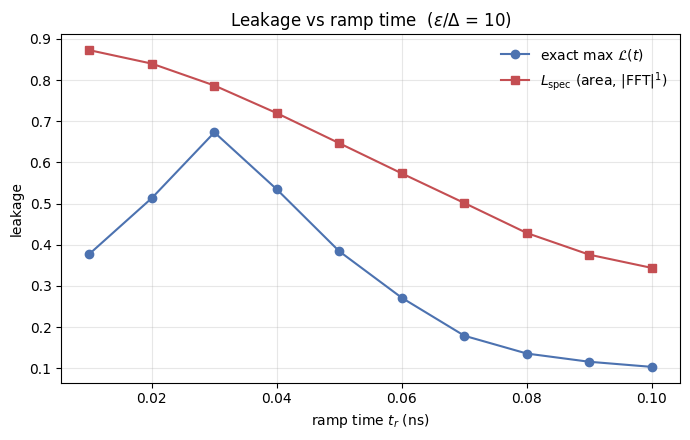

In [52]:
# --- plot ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ramp_times, L_exact_arr, 'o-', color='#4c72b0', label='exact max $\\mathcal{L}(t)$')
ax.plot(ramp_times, L_spec_arr, 's-', color='#c44e52',
        label=f'$L_{{\\rm spec}}$ (area, |FFT|$^{AREA_POWER_SWEEP}$)')
ax.set_xlabel('ramp time $t_r$ (ns)')
ax.set_ylabel('leakage')
ax.set_title(f'Leakage vs ramp time  ($\\epsilon/\\Delta$ = {sweep_eps_over_delta})')
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)
plt.tight_layout()

In [ ]:
# --- save figure + data ---
# One level above the git project root (the repo is `lsz_spectroscopy/` and this
# notebook lives in `notebooks/`, so `../..` is the folder just outside the repo).
RESULTS = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'results'))
os.makedirs(RESULTS, exist_ok=True)
stamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
base = os.path.join(RESULTS, f'leakage_vs_ramp_eps{sweep_eps_over_delta:g}_{stamp}')

fig.savefig(base + '.png', dpi=200, bbox_inches='tight')
plt.show()

# numeric data: one npz (arrays) + one JSON (metadata + curves) + a CSV.
np.savez(base + '.npz',
         ramp_times=ramp_times, L_exact_max=L_exact_arr, L_spec=L_spec_arr,
         P_all=np.array(P_all), tw_list=tw_sweep,
         eps_over_delta=sweep_eps_over_delta, wait_time=sweep_wait_time,
         gap_plateau=gap_plateau_sweep, dphi=dphi_sweep, area_power=AREA_POWER_SWEEP)

meta = {
    'eps_over_delta': float(sweep_eps_over_delta),
    'wait_time': float(sweep_wait_time),
    'dt': float(dt),
    'N_keep': int(N_keep),
    'gap_plateau': float(gap_plateau_sweep),
    'dphi': float(dphi_sweep),
    'area_power': int(AREA_POWER_SWEEP),
    'ramp_times': ramp_times.tolist(),
    'L_exact_max': L_exact_arr.tolist(),
    'L_spec': L_spec_arr.tolist(),
}
with open(base + '.json', 'w') as fh:
    json.dump(meta, fh, indent=2)

np.savetxt(base + '.csv',
           np.column_stack([ramp_times, L_exact_arr, L_spec_arr]),
           delimiter=',', header='ramp_time,L_exact_max,L_spec', comments='')

print(f"\nsaved:\n  {base}.png\n  {base}.npz\n  {base}.json\n  {base}.csv")


saved:
  /Users/omichel/Desktop/qilimanjaro/projects/LZS_spectroscopy/results/leakage_vs_ramp_eps1_20260921_113042.png
  /Users/omichel/Desktop/qilimanjaro/projects/LZS_spectroscopy/results/leakage_vs_ramp_eps1_20260921_113042.npz
  /Users/omichel/Desktop/qilimanjaro/projects/LZS_spectroscopy/results/leakage_vs_ramp_eps1_20260921_113042.json
  /Users/omichel/Desktop/qilimanjaro/projects/LZS_spectroscopy/results/leakage_vs_ramp_eps1_20260921_113042.csv
